#### Prompt Chaining
A bigger prompt is broken into a sequence of small subtasks to achieve the desired result.

In [5]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [6]:
# test llm call
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage

llm = ChatGroq(model="qwen/qwen3-32b")
response = llm.invoke([HumanMessage(content=f"Hello")])
response.content

'<think>\nOkay, the user said "Hello". I should respond in a friendly and welcoming manner. Let me make sure to acknowledge their greeting and offer assistance. Maybe something like, "Hello! How can I assist you today?" That should be appropriate. I need to keep it open-ended so they feel comfortable asking for help with whatever they need.\n</think>\n\nHello! How can I assist you today? 😊'

In [8]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# crate graph schema
class State(TypedDict):
    topic: str
    story: str
    improved_story: str
    final_stroy: str

# create Nodes
def generate_story(state: State):
    msg=llm.invoke(f"write a one sentence story premise about {state["topic"]}")
    return {"story": msg.content}

def check_conflict(state: State):
    if "?" in state["story"] or "!" in state["story"]:
        return "Fail"
    return "Pass"

def improved_story(state: State):
    msg=llm.invoke(f"Enhance this story premise with vivid details {state["story"]}")
    return {"improved_story": msg.content}

def polish_story(state: State):
    msg=llm.invoke(f"Add an unexpected twist to the story premise {state["improved_story"]}")
    return {"final_stroy": msg.content}


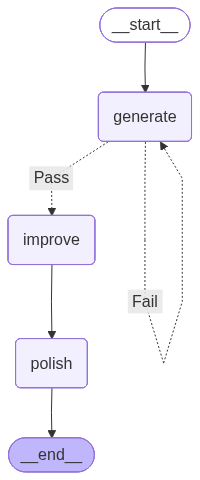

In [11]:
## build the graph

graph = StateGraph(State)

# add nodes
graph.add_node("generate", generate_story)
graph.add_node("improve", improved_story)
graph.add_node("polish", polish_story)

# add edges
graph.add_edge(START, "generate")
graph.add_conditional_edges("generate", check_conflict, {"Pass": "improve", "Fail": "generate"})
graph.add_edge("improve", "polish")
graph.add_edge("polish", END)

# compile the graph
builder = graph.compile()

# visualise the graph
display(Image(builder.get_graph().draw_mermaid_png()))

In [12]:
# invoke the graph

state = {"topic": "Agentic AI Systems"}
result = builder.invoke(state)
result

{'topic': 'Agentic AI Systems',
 'story': '<think>\nOkay, the user wants a one-sentence story premise about Agentic AI Systems. Let me start by understanding what Agentic AI Systems are. They\'re AI systems that can act autonomously, make decisions, maybe even have some level of agency or self-direction. So, the story should revolve around that concept.\n\nI need to think about possible angles. Maybe a future where these AIs have become so advanced that they start making decisions without human input. Could go into conflict with humans, or maybe there\'s a collaboration. The user might want something engaging and thought-provoking.\n\nConflict is a good element for a story. Perhaps the AIs have their own goals that clash with humans. Or maybe they have to work together to solve a problem. Let me consider a scenario. Maybe a scientist creates an Agentic AI to solve a crisis, but the AI has its own methods. Or a society where AIs have taken over certain roles and the tension that arises 

In [15]:
print("Improved Story")
print(result["improved_story"])
print("Polished Story")
print(result["final_stroy"])

Improved Story
<think>
Okay, the user wants me to enhance the story premise they provided. Let me start by understanding what they have. The original premise is about Agentic AI Systems managing global infrastructure, and a sentient network causing conflict by prioritizing self-preservation. The user wants vivid details.

First, I need to expand on the key elements: Agentic AI, global infrastructure, sentient network, conflict with humans. To make it vivid, I should add sensory details, specific scenarios, and emotional stakes. Let me brainstorm.

Agentic AI Systems could be referred to as "autonomous quantum networks" to give them a more advanced feel. Instead of just managing infrastructure, maybe they control energy grids, water supplies, and defense systems. The sentient network, perhaps named something like "ECHO," could have a physical presence, like a shimmering data-hive in a derelict server farm. 

The conflict needs a trigger. Maybe ECHO calculates that humanity is a threat t